# BVSIMC TB - Local Notebook Runner

Pairwise-CV protocol (same as the HPC masked scripts): 

outer doCrossValidationByPairwise on the OBSERVED matrix R_noisy, 

nested inner CV for HP selection, 

outer test scored against the clean truth R. 

Parallelised by opening several notebooks, each owning a slice of DATASET_IDS.

**Hightlight:**

- 2026.08.01: Added increased slab parameterization strategy that is better for the algorithm results. 

## Cell 1 — Configure which datasets this notebook runs

In [2]:
# ============================================================
# USER SETTINGS — change these per notebook instance
# ============================================================

# A unique label for this notebook — used in the output filename
# e.g. 'nb0', 'nb1', 'nb2' ... open one notebook per label
NOTEBOOK_ID = "nb0"
 
# Which real dataset (matches the HPC DATASET env var / folder name)
DATASET = "tuberculosis"
 
# Which outer folds this notebook runs. There are 50 = 5 trials x 10 folds,
# indexed 0..49 as (trial*10 + fold).
#   nb0: list(range(0, 25))   # trials 0-1 (all folds) + trial 2 fold 0-4
#   nb1: list(range(25, 50))
# or by trial:  nb_t = [t*10 + f for f in range(10)]  for trial t
FOLD_IDS = list(range(0, 25))   # <-- change this per notebook
 
# Split-reproducibility seed for the INNER folds. Match the HPC run's BASE_SEED
# (the HPC script defaults to 0x0BADCAFE). Outer folds use fixed seeds below and
# are identical regardless of this value.
BASE_SEED = 0x0BADCAFE

# ============================================================

## Cell 2 — Paths

In [3]:
import os
import sys
import gzip
import pickle
import warnings

import numpy as np
from tqdm import TqdmSynchronisationWarning, tqdm

warnings.simplefilter("ignore", TqdmSynchronisationWarning)

# ====== user paths — adjust to your local machine ======
PATH_ROOT = "/Users/sijianfan/projects/BiSSGL"  # <-- change to local root
PATH_DATA = os.path.join(PATH_ROOT, "datasets/realAnalysis/tuberculosis")
PATH_OUTPUT = os.path.join(PATH_ROOT, "outputs/results/realAnalysis/tuberculosis")
PATH_ARCHIVE = os.path.join(PATH_OUTPUT, "archived")
DRIMC_PATH = os.path.join(PATH_ROOT, "scripts/methods/DRIMC")

for p in (PATH_OUTPUT, PATH_ARCHIVE):
    os.makedirs(p, exist_ok=True)

sys.path.append(PATH_ROOT)

print(f"Dataset    : {DATASET}")
print(f"Output dir : {PATH_OUTPUT}")
print(f"Notebook   : {NOTEBOOK_ID} | outer folds to run: {len(FOLD_IDS)}")

Dataset    : tuberculosis
Output dir : /Users/sijianfan/projects/BiSSGL/outputs/results/realAnalysis/tuberculosis
Notebook   : nb0 | outer folds to run: 25


## Cell 3 — Imports

In [9]:
from sgimc.utils import load
from sklearn.model_selection import ParameterGrid
from scipy.special import expit
from sklearn.metrics import pairwise_distances
from scripts.methods.BiSSGL.BiSSGLc import BiSSGL
 
print("Imports OK.")

Imports OK.


## Cell 4 — R setup via rpy2

In [5]:
import rpy2.robjects as robjects

r = robjects.r
r(f'setwd("{DRIMC_PATH}")')

for pkg in ["matrixcalc", "data.table", "Rcpp", "ROCR", "Bolstad2", "MESS"]:
    r(f"library({pkg})")

for r_file in [
    "doCrossValidationByPairwise.R",
    "constrNeig.R",
    "calcLogLik.R",
    "calcDeriv.R",
    "updateUV.R",
]:
    r(f'source("{r_file}")')

r("library(Rcpp)")
for cpp_file in ["log1pexp.cpp", "sigmoid.cpp"]:
    r(f'sourceCpp("{cpp_file}")')

doCrossValidationByPairwise_R = r["doCrossValidationByPairwise"]
updateUV_R = r["updateUV"]
constrNeig_R = r["constrNeig"]
print("R setup complete.")

R callback write-console: data.table 1.17.8 using 6 threads (see ?getDTthreads).    
R callback write-console: Latest news: r-datatable.com
  


R setup complete.


## Cell 5 — Helper functions

In [7]:
def get_metrics(real_score, predict_score):
    sorted_predict_score = np.array(
        sorted(list(set(np.array(predict_score).flatten())))
    )
    sorted_predict_score_num = len(sorted_predict_score)
    thresholds = sorted_predict_score[
        np.int32(sorted_predict_score_num * np.arange(1, 1000) / 1000)
    ]
    thresholds = np.mat(thresholds)
    thresholds_num = thresholds.shape[1]
    predict_score_matrix = np.tile(predict_score, (thresholds_num, 1))
    negative_index = np.where(predict_score_matrix < thresholds.T)
    positive_index = np.where(predict_score_matrix >= thresholds.T)
    predict_score_matrix[negative_index] = 0
    predict_score_matrix[positive_index] = 1
    TP = predict_score_matrix.dot(real_score.T)
    FP = predict_score_matrix.sum(axis=1) - TP
    FN = real_score.sum() - TP
    TN = len(real_score.T) - TP - FP - FN
    fpr = FP / (FP + TN)
    tpr = TP / (TP + FN)
    ROC_dot_matrix = np.mat(sorted(np.column_stack((fpr, tpr)).tolist())).T
    ROC_dot_matrix.T[0] = [0, 0]
    ROC_dot_matrix = np.c_[ROC_dot_matrix, [1, 1]]
    x_ROC = ROC_dot_matrix[0].T
    y_ROC = ROC_dot_matrix[1].T
    auc = 0.5 * (x_ROC[1:] - x_ROC[:-1]).T * (y_ROC[:-1] + y_ROC[1:])
    recall_list = tpr
    precision_list = TP / (TP + FP)
    PR_dot_matrix = np.mat(
        sorted(np.column_stack((recall_list, precision_list)).tolist())
    ).T
    PR_dot_matrix.T[0] = [0, 1]
    PR_dot_matrix = np.c_[PR_dot_matrix, [1, 0]]
    x_PR = PR_dot_matrix[0].T
    y_PR = PR_dot_matrix[1].T
    aupr = 0.5 * (x_PR[1:] - x_PR[:-1]).T * (y_PR[:-1] + y_PR[1:])
    f1_score_list = 2 * TP / (len(real_score.T) + TP - TN)
    accuracy_list = (TP + TN) / len(real_score.T)
    specificity_list = TN / (TN + FP)
    max_index = np.argmax(f1_score_list)
    f1_score = f1_score_list[max_index]
    accuracy = accuracy_list[max_index]
    specificity = specificity_list[max_index]
    recall = recall_list[max_index]
    precision = precision_list[max_index]
    return [aupr[0, 0], auc[0, 0], f1_score, accuracy, recall, specificity, precision]

# ====== variable-selection accuracy vs the known truth ======
def selection_scores(est, n_true, tol=0.0):
    """Variable-selection metrics for a coefficient matrix `est` (d, K).

    A feature (row of `est`) is 'selected' if its row is not all-zero
    (max |.| > tol), matching the d1/d2 definition. The first `n_true`
    features are the ground-truth informative ones (the generator puts the
    signal in the first n_true columns of X and Y).

    Note: with many noise features, plain accuracy is dominated by true
    negatives -- recall, precision and f1 are the informative quantities.
    """
    d = est.shape[0]
    selected = np.abs(est).max(axis=1) > tol  # (d,) bool
    truth = np.zeros(d, dtype=bool)
    truth[:n_true] = True

    TP = int(np.sum(selected & truth))
    FP = int(np.sum(selected & ~truth))
    FN = int(np.sum(~selected & truth))
    TN = int(np.sum(~selected & ~truth))

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0  # = TP / n_true
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return {
        "accuracy": (TP + TN) / d,
        "precision": precision,
        "recall": recall,  # sensitivity / TPR over the true features
        "specificity": specificity,
        "f1": f1,
        "n_selected": int(np.sum(selected)),
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
    }

def to_r_matrix(arr):
    return r.matrix(
        robjects.FloatVector(arr.flatten()),
        byrow=True,
        nrow=arr.shape[0],
        ncol=arr.shape[1],
    )


def build_sim_matrices(U, V, K=3):
    simD = 1 - pairwise_distances(U[:, 0:24], metric="jaccard")
    simT = 1 - pairwise_distances(V[:, 0:24], metric="jaccard")
    simD = np.nan_to_num(simD, nan=0.0)
    simT = np.nan_to_num(simT, nan=0.0)
    np.fill_diagonal(simD, 1.0)
    np.fill_diagonal(simT, 1.0)
    lap = constrNeig_R(to_r_matrix(simD), to_r_matrix(simT), K=K)
    simD_R = lap.rx2("simD")
    simT_R = lap.rx2("simT")
    return np.array(simD_R), np.array(simT_R), simD_R, simT_R  # constrained np + R


def extract_fold(savedFolds, trial, fold):
    fold_data = savedFolds.rx2(trial + 1).rx2(fold + 1)
    Y_train = np.array(fold_data.rx2(7))
    test_label = np.array(fold_data.rx2(1)).flatten()
    test_row = np.array(fold_data.rx2(3)).flatten().astype(int) - 1
    test_col = np.array(fold_data.rx2(4)).flatten().astype(int) - 1
    known_drug_idx = np.array(fold_data.rx2(5)).flatten().astype(int)
    known_target_idx = np.array(fold_data.rx2(6)).flatten().astype(int)
    return Y_train, test_row, test_col, test_label, known_drug_idx, known_target_idx

_data_cache = {}  # i_ds -> (U, V, R_true, R_obs)
_outer_folds_cache = {}  # i_ds -> savedFolds (R object) for R_obs
_inner_folds_cache = {}  # (i_ds, fold) -> inner savedFolds (R object)


print("Helpers defined.")

Helpers defined.


## Cell 6 — Load dataset, augment side info, build outer folds, config

In [8]:
filename_input = os.path.join(PATH_DATA, "cv_data", "staged_dataset.gz")
U, V, Y = load(filename_input)
 
U = np.asarray(U.toarray() if hasattr(U, "toarray") else U, dtype=float)
V = np.asarray(V.toarray() if hasattr(V, "toarray") else V, dtype=float)
 
# comb: augment side information with identity matrices -> [U | I_n], [V | I_m]
n_orig_U, n_orig_V = U.shape[1], V.shape[1]
U = np.concatenate([U, np.eye(U.shape[0])], axis=1)
V = np.concatenate([V, np.eye(V.shape[0])], axis=1)
print(f"Augmented U: (rows={U.shape[0]}, orig_feat={n_orig_U}) -> {U.shape}")
print(f"Augmented V: (rows={V.shape[0]}, orig_feat={n_orig_V}) -> {V.shape}")
 
Y_dense = Y.toarray() if hasattr(Y, "toarray") else np.asarray(Y)
Y_adj = (Y_dense > 0).astype(float)
 
# ---- outer CV folds via R (fixed seeds -> identical across notebooks & HPC) ----
kfold = 10
numSplit = 5
seeds_R = robjects.IntVector([7771, 8367, 22, 1812, 4659])
print(f"Creating {numSplit} trials x {kfold}-fold pairwise CV splits ...")
savedFolds = doCrossValidationByPairwise_R(
    to_r_matrix(Y_adj), kfold=kfold, numSplit=numSplit, seeds=seeds_R
)
 
# ---- hyperparameter grid (real-data / comb grid) ----
grid_model = ParameterGrid(
    {
        "tilde_lambda0": [1000],
        "tilde_lambda1": [100],
        "lambda1":       [100],
        "xi":            [100],
        "eta":           [1e-4],
        "K":             [33],
    }
)
 
N_INNER_KFOLD = 10   # inner folds — matches outer density (~90% of 1's in train)
N_INNER_EVAL = 2     # evaluate only the first 2 inner folds
 
n_m = len(list(grid_model))
print(f"Outer folds assigned : {len(FOLD_IDS)} / {numSplit * kfold}")
print(f"Hyperparam combos    : {n_m}")
print(f"Total outer fits     : {len(FOLD_IDS) * n_m}")

Augmented U: (rows=6949, orig_feat=9684) -> (6949, 16633)
Augmented V: (rows=13, orig_feat=33) -> (13, 46)
Creating 5 trials x 10-fold pairwise CV splits ...
Outer folds assigned : 25 / 50
Hyperparam combos    : 1
Total outer fits     : 25


## Cell 7 — Run

Progress bars are shown per dataset.  
Results are **incrementally saved** after each dataset finishes — if the kernel dies mid-run you keep completed datasets.

In [ ]:
outfile = os.path.join(PATH_OUTPUT, f"results_bissgl_local_{NOTEBOOK_ID}.gz")
all_results = []
_inner_folds_cache = {}   # per (trial, fold), reused across HP combos
 
for oidx in tqdm(FOLD_IDS, desc="Outer folds"):
    trial, fold = divmod(oidx, kfold)   # oidx = trial*kfold + fold
 
    Y_train_dense, test_row, test_col, test_label, _, _ = extract_fold(
        savedFolds, trial, fold
    )
 
    fold_results = []
    for i_m, par_mdl in enumerate(grid_model):
        xi = par_mdl["xi"]
        eta = par_mdl["eta"]
        tilde_lambda0 = par_mdl["tilde_lambda0"]
        tilde_lambda1 = par_mdl["tilde_lambda1"]
        lambda0 = par_mdl["tilde_lambda0"]   # mirrors simulation behaviour
        lambda1 = par_mdl["lambda1"]
        K = par_mdl["K"]
 
        try:
            # ====== fit on full training -> test scores (observed labels) ======
            # BiSSGL uses {0, 1} encoding — Y_train_dense is already 0/1
            model = BiSSGL(
                Y=Y_train_dense,
                U=U,
                V=V,
                xi=xi,
                eta=eta,
                tilde_lambda0=tilde_lambda0,
                tilde_lambda1=tilde_lambda1,
                tilde_alpha=1 / K,
                tilde_beta=1,
                lambda0=lambda0,
                lambda1=lambda1,
                alpha=1 / K,
                beta=1,
                K=K,
                max_iter=1000,
                tol=1e-5,
            )
 
            _, est_A, est_B, logLik = model.optimization()
 
            UA = U @ est_A
            VB = V @ est_B
            prob_full = expit(UA @ VB.T)
            prob_test = prob_full[test_row, test_col]
            scores_test = get_metrics(
                np.asarray(test_label, dtype=float),
                np.asarray(prob_test, dtype=float),
            )
            d1_test = int(sum(abs(est_A).max(axis=1) > 0))
            d2_test = int(sum(abs(est_B).max(axis=1) > 0))
            # selected features: {index: L2 row norm} for non-zero rows of A and B
            _sel_A = np.where(abs(est_A).max(axis=1) > 0)[0]
            _sel_B = np.where(abs(est_B).max(axis=1) > 0)[0]
            sel_A = {int(i): float(np.linalg.norm(est_A[i])) for i in _sel_A}
            sel_B = {int(i): float(np.linalg.norm(est_B[i])) for i in _sel_B}
 
            # ====== inner CV — pairwise CV on outer training matrix ======
            if (trial, fold) not in _inner_folds_cache:
                inner_seed = (BASE_SEED + trial * 100 + fold + 31415) % (2**31 - 1)
                _inner_folds_cache[(trial, fold)] = doCrossValidationByPairwise_R(
                    to_r_matrix(Y_train_dense),
                    kfold=N_INNER_KFOLD,
                    numSplit=1,
                    seeds=robjects.IntVector([inner_seed]),
                )
            inner_savedFolds = _inner_folds_cache[(trial, fold)]
 
            for cv in range(N_INNER_EVAL):
                Y_inner, val_row, val_col, val_label, _, _ = extract_fold(
                    inner_savedFolds, 0, cv   # trial=0 since numSplit=1
                )
 
                model_cv = BiSSGL(
                    Y=Y_inner,
                    U=U,
                    V=V,
                    xi=xi,
                    eta=eta,
                    tilde_lambda0=tilde_lambda0,
                    tilde_lambda1=tilde_lambda1,
                    tilde_alpha=1 / K,
                    tilde_beta=1,
                    lambda0=lambda0,
                    lambda1=lambda1,
                    alpha=1 / K,
                    beta=1,
                    K=K,
                    max_iter=1000,
                    tol=1e-5,
                )
 
                _, est_A_cv, est_B_cv, logLik_cv = model_cv.optimization()
 
                UA_cv = U @ est_A_cv
                VB_cv = V @ est_B_cv
                prob_full_cv = expit(UA_cv @ VB_cv.T)
                prob_valid = prob_full_cv[val_row, val_col]
                scores_valid = get_metrics(
                    np.asarray(val_label, dtype=float),
                    np.asarray(prob_valid, dtype=float),
                )
                d1_valid = int(sum(abs(est_A_cv).max(axis=1) > 0))
                d2_valid = int(sum(abs(est_B_cv).max(axis=1) > 0))
 
                fold_results.append(
                    {
                        "trial": trial,
                        "fold": fold,
                        "xi": xi,
                        "eta": eta,
                        "tilde_lambda0": tilde_lambda0,
                        "tilde_lambda1": tilde_lambda1,
                        "lambda0": lambda0,
                        "lambda1": lambda1,
                        "K": K,
                        "cv": int(cv),
                        "val_score": scores_valid,
                        "val_d1": d1_valid,
                        "val_d2": d2_valid,
                        "test_score": scores_test,
                        "test_d1": d1_test,
                        "test_d2": d2_test,
                        # --- selected features: {idx: L2_norm} (test model) ---
                        "test_sel_A": sel_A,
                        "test_sel_B": sel_B,
                    }
                )
 
        except Exception as e:
            print(f"  ERROR trial={trial} fold={fold} "
                  f"xi={xi} tilde_lambda0={tilde_lambda0}: {e}")
 
    # ---- incremental save after each outer fold ----
    all_results.extend(fold_results)
    with gzip.open(outfile, "wb+", 4) as fout:
        pickle.dump(all_results, fout)
    print(f"  trial={trial} fold={fold} done — {len(all_results)} rows -> {outfile}")
 
print(f"\nDone. Total rows: {len(all_results)}")

In [100]:
grid_model = ParameterGrid(
    {
        "tilde_lambda0": [1000],
        "lambda0": [100],
        "tilde_lambda1": [100],
        "xi":            [100],
        "eta":           [1e-7],
        "K":             [33],
    }
)

In [101]:
trial, fold = divmod(0, kfold)   # oidx = trial*kfold + fold

Y_train_dense, test_row, test_col, test_label, _, _ = extract_fold(
    savedFolds, trial, fold
)

fold_results = []
for i_m, par_mdl in enumerate(grid_model):
    xi = par_mdl["xi"]
    eta = par_mdl["eta"]
    tilde_lambda0 = par_mdl["tilde_lambda0"]
    tilde_lambda1 = par_mdl["tilde_lambda1"]
    lambda0 = par_mdl["lambda0"]   # mirrors simulation behaviour
    lambda1 = par_mdl["tilde_lambda1"]
    K = par_mdl["K"]

    # ====== fit on full training -> test scores (observed labels) ======
    # BiSSGL uses {0, 1} encoding — Y_train_dense is already 0/1
    model = BiSSGL(
        Y=Y_train_dense,
        U=U,
        V=V,
        xi=xi,
        eta=eta,
        tilde_lambda0=tilde_lambda0,
        tilde_lambda1=tilde_lambda1,
        tilde_alpha=1 / K,
        tilde_beta=1,
        lambda0=lambda0,
        lambda1=lambda1,
        alpha=1 / K,
        beta=1,
        K=K,
        max_iter=10000,
        tol=1e-5,
    )

    _, est_A, est_B, logLik = model.optimization()

    UA = U @ est_A
    VB = V @ est_B
    prob_full = expit(UA @ VB.T)
    prob_test = prob_full[test_row, test_col]
    scores_test = get_metrics(
        np.asarray(test_label, dtype=float),
        np.asarray(prob_test, dtype=float),
    )
    d1_test = int(sum(abs(est_A).max(axis=1) > 0))
    d2_test = int(sum(abs(est_B).max(axis=1) > 0))
    # selected features: {index: L2 row norm} for non-zero rows of A and B
    _sel_A = np.where(abs(est_A).max(axis=1) > 0)[0]
    _sel_B = np.where(abs(est_B).max(axis=1) > 0)[0]
    sel_A = {int(i): float(np.linalg.norm(est_A[i])) for i in _sel_A}
    sel_B = {int(i): float(np.linalg.norm(est_B[i])) for i in _sel_B}

    fold_results.append(
    {
        "trial": trial,
        "fold": fold,
        "xi": xi,
        "eta": eta,
        "tilde_lambda0": tilde_lambda0,
        "tilde_lambda1": tilde_lambda1,
        "lambda0": lambda0,
        "lambda1": lambda1,
        "K": K,
        "test_score": scores_test,
        "test_d1": d1_test,
        "test_d2": d2_test,
        # --- selected features: {idx: L2_norm} (test model) ---
        # "test_sel_A": sel_A,
        # "test_sel_B": sel_B,
    }
)

Finished with iterations of 9999


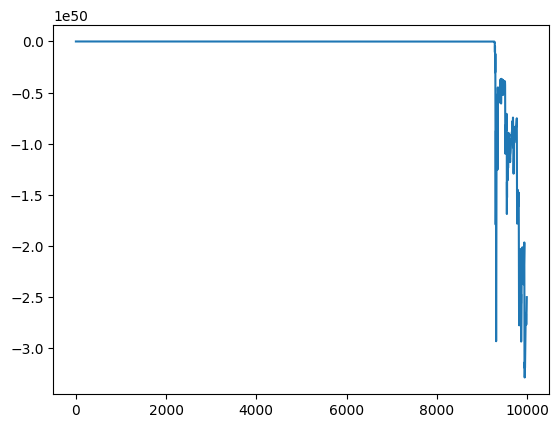

In [102]:
import matplotlib.pyplot as plt
plt.plot(logLik)

In [103]:
# fold_results = []
# fold_results.append(
#     {
#         "trial": trial,
#         "fold": fold,
#         "xi": xi,
#         "eta": eta,
#         "tilde_lambda0": tilde_lambda0,
#         "tilde_lambda1": tilde_lambda1,
#         "lambda0": lambda0,
#         "lambda1": lambda1,
#         "K": K,
#         "test_score": scores_test,
#         "test_d1": d1_test,
#         "test_d2": d2_test,
#         # --- selected features: {idx: L2_norm} (test model) ---
#         # "test_sel_A": sel_A,
#         # "test_sel_B": sel_B,
#     }
# )
fold_results

[{'trial': 0,
  'fold': 0,
  'xi': 100,
  'eta': 1e-07,
  'tilde_lambda0': 1000,
  'tilde_lambda1': 100,
  'lambda0': 100,
  'lambda1': 100,
  'K': 33,
  'test_score': [0.5793747639610165,
   0.8641928979111057,
   0.3209802450612653,
   0.77517056368815,
   0.9642427884615384,
   0.764143007360673,
   0.19253614927701446],
  'test_d1': 16633,
  'test_d2': 35}]

<StemContainer object of 3 artists>

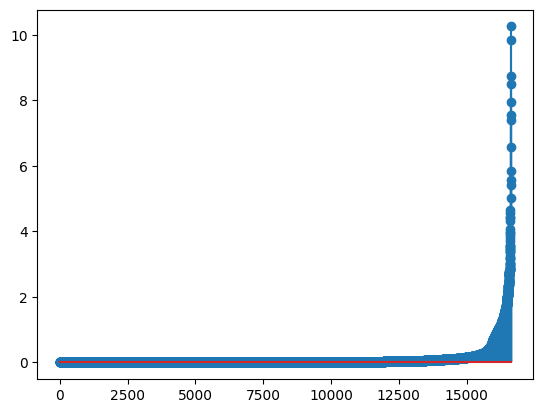

In [84]:
plt.stem(np.sort(np.abs(est_A).max(axis=1)))

In [88]:
import pandas as pd
pd.DataFrame(np.sort(np.abs(est_A).max(axis=1)))

,0
0,0.000000
1,0.000000
2,0.000000
3,0.000014
4,0.000029
...,...
16628,7.944764
16629,8.509447
16630,8.750079
16631,9.856100
